In [80]:
import glob
import fitsio
from astropy.table import Table
import matplotlib.pyplot as plt
import numpy as np
import healpy as hp
import scienceplots
plt.style.use(['science', 'notebook', 'grid'])  
import os

In [81]:
north_masks={}
south_masks={}
full_masks={}

for region in ['north', 'south', 'full']:
    if region == 'north':
        target_dict = north_masks
    elif region == 'south':
        target_dict = south_masks
    else:
        target_dict = full_masks

    for nside in [32,64,128]:
        target_dict[nside] = hp.read_map(f"imaging_systematics_maps/data/{region}_mask_nside_{nside}_for_systmatics_20M.fits")

In [82]:
randoms=fitsio.FITS('/user/animesh.sah/FP_CUTS/randoms_with_mags.fits')[1].read()
randoms =randoms[randoms['DEC']>-30]



In [83]:
csfd_map = hp.read_map('/user/animesh.sah/csfd_maps/csfd_ebv.fits')
stellar_density_allwise = hp.read_map('/user/animesh.sah/Stellar_density/allwise_total_rot_1024.fits')
h_alpha = hp.read_map('/user/animesh.sah/Halpha_maps/Halpha_fwhm06_1024.fits')


csfd_map = np.where(np.isfinite(csfd_map), csfd_map, np.nan)

rot = hp.Rotator(coord=['G','C'])
csfd_eq = rot.rotate_map_pixel(csfd_map)
h_alpha_eq = rot.rotate_map_pixel(h_alpha)


In [84]:
##masking 

h_alpha_mask_1 = hp.read_map('/user/animesh.sah/Halpha_maps/Halpha_mask_fwhm06_1024.fits')
M = h_alpha_mask_1  # integer bitmask map

good = (
    ((M & (1<<3)) == 0)   # no STAR
    & ((M & (1<<4)) == 0) # no SATUR
    & ((M & (1<<5)) == 0) # no BRT_OBJ
    & ((M & (1<<6)) == 0) # no BIG_OBJ
    & ((M & (1<<7)) == 0) # no HI_VEL
)
h_alpha_mask  = rot.rotate_map_pixel(good.astype(float))



In [7]:
colnames = ['PSFDEPTH_Z','PSFDEPTH_G','PSFDEPTH_R','PSFSIZE_G','PSFSIZE_R','PSFSIZE_Z']
# Randomly sample 20M points
n_sample = min(20_000_000, len(randoms))
indices = np.random.choice(len(randoms), size=n_sample, replace=False)


ra_array_full = randoms['RA'][indices]
dec_array_full = randoms['DEC'][indices]
randoms_full = randoms[indices]

randoms_south = randoms_full[randoms_full['PHOTSYS'] == 'S']
randoms_north = randoms_full[randoms_full['PHOTSYS'] == 'N']


In [8]:
def get_mask(ra,dec,nside):
    theta = np.radians(90 -dec)
    phi = np.radians(ra)
    pix = hp.ang2pix(nside, theta, phi)
    mask = np.bincount(pix, minlength=hp.nside2npix(nside))
    mask = np.where(mask>0, 1, 0)
    return mask
def create_rand_map(part,nside):
    random_compiled = randoms_full
    rand_table=Table(random_compiled)
    rand_table = rand_table[rand_table['DEC'] > -30]

    if part == 'N':
        rand_table = rand_table[rand_table['PHOTSYS'] == 'N']
    elif part == 'S':
        rand_table = rand_table[rand_table['PHOTSYS'] == 'S']
    RA_random = np.ascontiguousarray(np.array(rand_table['RA'], dtype=np.float64))
    DEC_random= np.ascontiguousarray(np.array(rand_table['DEC'], dtype=np.float64))
    rand_map = get_mask(RA_random, DEC_random, nside)
    return rand_map

In [ ]:
# north_masks={}
# south_masks={}
# full_masks={}

# for nside in [32,64,128]:
#     north_masks[nside] = create_rand_map('N',nside)
#     south_masks[nside] = create_rand_map('S',nside)
#     full_masks[nside]  = create_rand_map(None,nside)

# for masks in [north_masks, south_masks, full_masks]:
#     for nside in masks:
#         # Determine the region name based on the variable name
#         if masks is north_masks:
#             region = "north"
#         elif masks is south_masks:
#             region = "south"
#         else:
#             region = "full"
#         hp.write_map(f"{region}_mask_nside_{nside}_for_systmatics_20M.fits", masks[nside], overwrite=True)
#         print(f"Saved {region} mask with nside {nside} to {region}_mask_nside_{nside}_for_systmatics_20M.fits")

setting the output map dtype to [dtype('int64')]
setting the output map dtype to [dtype('int64')]
setting the output map dtype to [dtype('int64')]
setting the output map dtype to [dtype('int64')]
setting the output map dtype to [dtype('int64')]
setting the output map dtype to [dtype('int64')]
setting the output map dtype to [dtype('int64')]
setting the output map dtype to [dtype('int64')]
setting the output map dtype to [dtype('int64')]


Saved north mask with nside 32 to north_mask_nside_32_for_systmatics_20M.fits
Saved north mask with nside 64 to north_mask_nside_64_for_systmatics_20M.fits
Saved north mask with nside 128 to north_mask_nside_128_for_systmatics_20M.fits
Saved south mask with nside 32 to south_mask_nside_32_for_systmatics_20M.fits
Saved south mask with nside 64 to south_mask_nside_64_for_systmatics_20M.fits
Saved south mask with nside 128 to south_mask_nside_128_for_systmatics_20M.fits
Saved full mask with nside 32 to full_mask_nside_32_for_systmatics_20M.fits
Saved full mask with nside 64 to full_mask_nside_64_for_systmatics_20M.fits
Saved full mask with nside 128 to full_mask_nside_128_for_systmatics_20M.fits


In [7]:
print("Loaded all data.")   
print(f'Number of randoms in full: {len(randoms_full):,}')
print(f'Number of randoms in north: {len(randoms_north):,}')
print(f'Number of randoms in south: {len(randoms_south):,}')

Loaded all data.
Number of randoms in full: 20,000,000
Number of randoms in north: 5,947,958
Number of randoms in south: 14,052,042


In [9]:

os.makedirs('imaging_systematics_maps', exist_ok=True)

regions = {
    'full': randoms_full,
    'north': randoms_north,
    'south': randoms_south
}

masks_dict= {
    'full': full_masks,
    'north': north_masks,
    'south': south_masks
}

In [10]:
def build_mean_map(ra, dec, values, nside, nest=False):
    """
    Return (mean_map, counts_map) for given arrays.
    ra, dec: degrees arrays (1D)
    values: weights or values for averaging (same length)
    nside: healpix NSIDE (nest ordering)
    """
    theta = np.radians(90.0 - dec)
    phi = np.radians(ra)
    ipix = hp.ang2pix(nside, theta, phi, nest=nest)
    npix = hp.nside2npix(nside)
    # numeric arrays
    ipix = np.asarray(ipix, dtype=np.int64)
    vals = np.asarray(values, dtype=float)

    # numerator: sum of values in pixel
    num = np.bincount(ipix, weights=vals, minlength=npix).astype(float)
    # denominator: counts (for mean)
    den = np.bincount(ipix, minlength=npix).astype(float)

    out = np.full(npix, np.nan, dtype=float)
    mask = den > 0
    out[mask] = num[mask] / den[mask]

    return out, den

def psfdepth_to_m5(psfdepth):
    # psfdepth may contain zeros or negative sentinel values
    arr = np.asarray(psfdepth, dtype=float)
    out = np.full(arr.shape, np.nan, dtype=float)
    good = arr > 0
    out[good] = -2.5 * (np.log10(5.0 / np.sqrt(arr[good])) - 9.0)
    return out

def points_to_map(ra_deg, dec_deg, nside, weights=None):
    theta = np.radians(90.0 - dec_deg)  
    phi   = np.radians(ra_deg)
    ipix  = hp.ang2pix(nside, theta, phi, nest=False)
    npix  = hp.nside2npix(nside)
    if weights is None:
        weights = np.ones_like(ipix, dtype=np.float64)
    m = np.bincount(ipix, weights=weights, minlength=npix).astype(np.float64)
    return m

In [11]:
# --- Build maps for a region (single nside) ---
def build_systematics_for_region(table, colnames, mask_nside_map, external_maps_nside, nside, nest=True):
    """
    table: astropy Table or dict-like with 'RA','DEC' and feature columns
    colnames: list of columns to produce maps for (strings)
    mask_nside_map: boolean array (npix,) where True = inside footprint (for that nside)
    external_maps_nside: dict with external maps already downgraded to this nside (e.g., CSFD, stellar, halpha)
    nside: int
    returns dict: maps[name] -> array (npix,) with np.nan outside footprint
    """
    maps = {}
    ra = np.asarray(table['RA'], dtype=float)
    dec = np.asarray(table['DEC'], dtype=float)

    # counts (for valid pixel detection)
    counts_map = build_mean_map(ra, dec, np.ones_like(ra), nside, nest=nest)[1]
    valid_pixels = counts_map > 0

    for col in colnames:
        if 'PSFDEPTH' in col:
            values = psfdepth_to_m5(table[col])
        else:
            values = np.asarray(table[col], dtype=float)
        mean_map, _ = build_mean_map(ra, dec, values, nside, nest=nest)
        # mask outside footprint
        mean_map_masked = np.where(mask_nside_map, mean_map, np.nan)
        # optional: force empty pixels (counts==0) to np.nan already
        mean_map_masked[~valid_pixels] = np.nan
        maps[col] = mean_map_masked

    # attach external maps (they should be arrays at same nside, same ordering)
    for name, extmap in external_maps_nside.items():
        maps[name] = np.where(mask_nside_map, extmap, np.nan)

    # also return counts_map (masked)
    counts_map_masked = np.where(mask_nside_map, counts_map, 0)
    return maps, counts_map_masked

In [12]:
nside_values_obj = [32,64,128]


In [41]:
h_alpha_nside = {} 
stellar_density_allwise_nside = {}
csfd_map_nside = {}
h_alpha_mask_nside = {}
for nside in nside_values_obj :
    h_alpha_nside[nside] = hp.ud_grade(h_alpha_eq, nside_out=nside, order_in='RING', order_out='RING', power=0)
    stellar_density_allwise_nside[nside] = hp.ud_grade(stellar_density_allwise, nside_out=nside, order_in='RING', order_out='RING', power=0)
    csfd_map_nside[nside] = hp.ud_grade(csfd_eq, nside_out=nside, order_in='RING', order_out='RING', power=0)
    h_alpha_mask_nside[nside] = hp.ud_grade(h_alpha_mask, nside_out=nside, order_in='RING', order_out='RING', power=0)

In [52]:
h_alpha_good_nside = {}
for nside in nside_values_obj:
    h_alpha_good = np.where(h_alpha_mask_nside[nside], h_alpha_nside[nside], hp.UNSEEN)
    h_alpha_good_nside[nside] = h_alpha_good


In [85]:
maps = {}

for region, region_data in regions.items():
    maps[region] = {}
    for nside_val in nside_values_obj:
        maps[region][nside_val] = {}
        mask_nside_map = masks_dict[region][nside_val]
        # prepare external maps at this nside
        ra = region_data['RA']
        dec = region_data['DEC']
        print(f"\nProcessing {region} region at nside={nside_val}")
        for val in colnames: 
            if 'PSFDEPTH' in val:
                values = psfdepth_to_m5(region_data[val])
            else:
                values = np.asarray(region_data[val], dtype=float)
            pix_map, _ = build_mean_map(ra, dec, values, nside_val)
            pix_map = np.where(mask_nside_map, pix_map, np.nan)
            maps[region][nside_val][val] = pix_map

        # external maps



        #csfd_map_masked = np.where(masks_dict[region][nside_val], csfd_map_nside[nside_val], hp.UNSEEN)
        #stellar_density_allwise_masked = np.where(masks_dict[region][nside_val], stellar_density_allwise_nside[nside_val], hp.UNSEEN)
        #h_alpha_masked = np.where(masks_dict[region][nside_val], h_alpha_nside[nside_val], hp.UNSEEN)
        #h_alpha_good_masked = np.where(masks_dict[region][nside_val], h_alpha_good_nside[nside_val], hp.UNSEEN)
        #maps[region][nside_val]['CSFD'] = csfd_map_masked
        #maps[region][nside_val]['Stellar_Density_AllWISE'] = stellar_density_allwise_masked
        #maps[region][nside_val]['H_Alpha'] = h_alpha_masked
        #maps[region][nside_val]['H_Alpha_Good'] = h_alpha_good_masked


            

        


Processing full region at nside=32

Processing full region at nside=64

Processing full region at nside=128

Processing north region at nside=32

Processing north region at nside=64

Processing north region at nside=128

Processing south region at nside=32

Processing south region at nside=64

Processing south region at nside=128


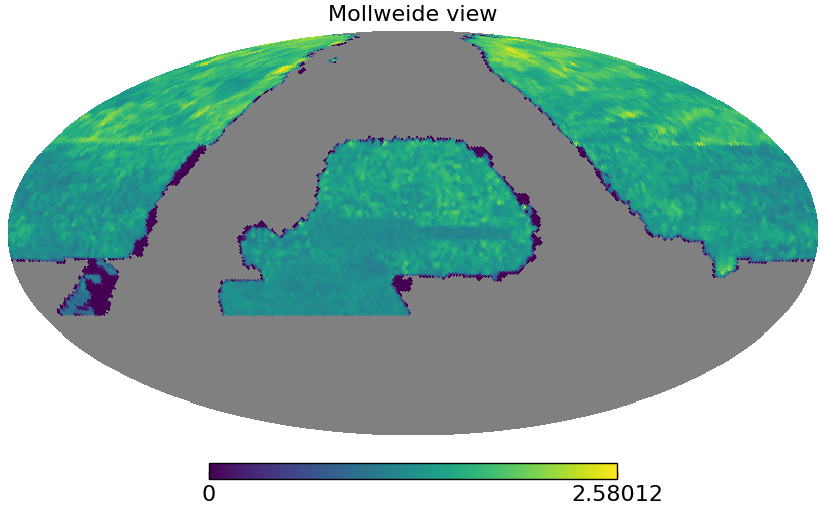

In [90]:
hp.mollview(maps['full'][64]['PSFSIZE_R'])

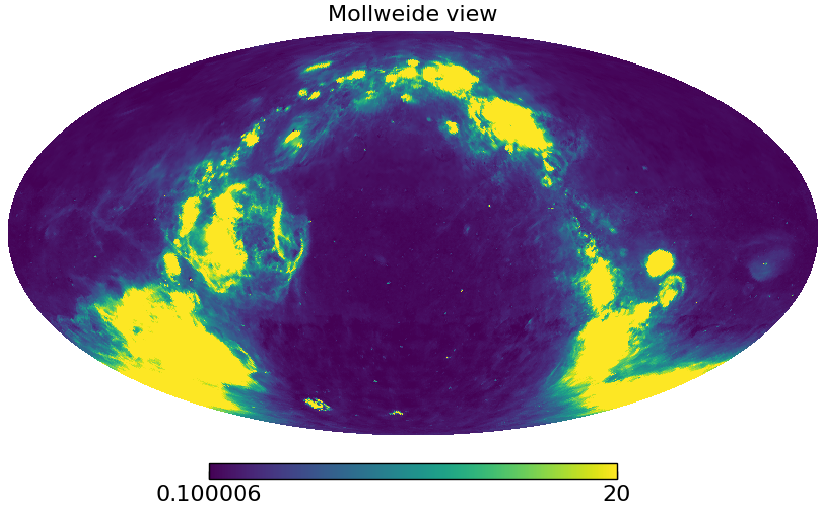

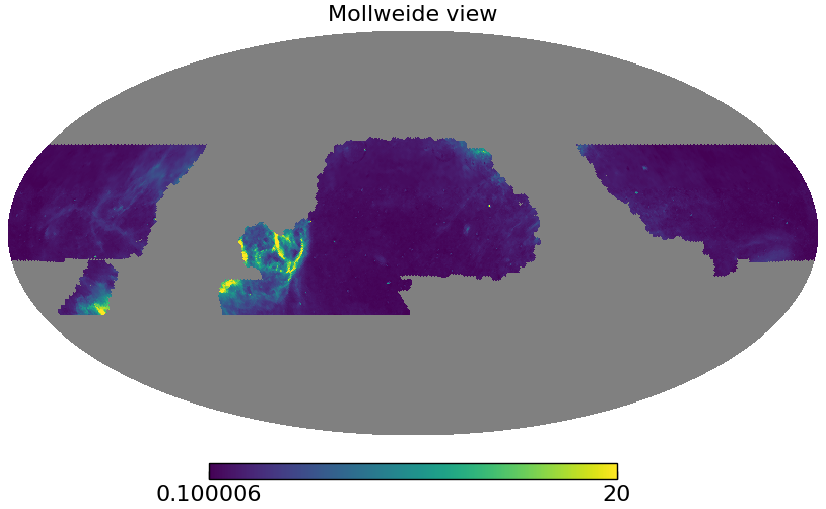

In [79]:
hp.mollview(h_alpha_nside[nside_val],max = 20)
hp.mollview(h_alpha_masked,max =20 )

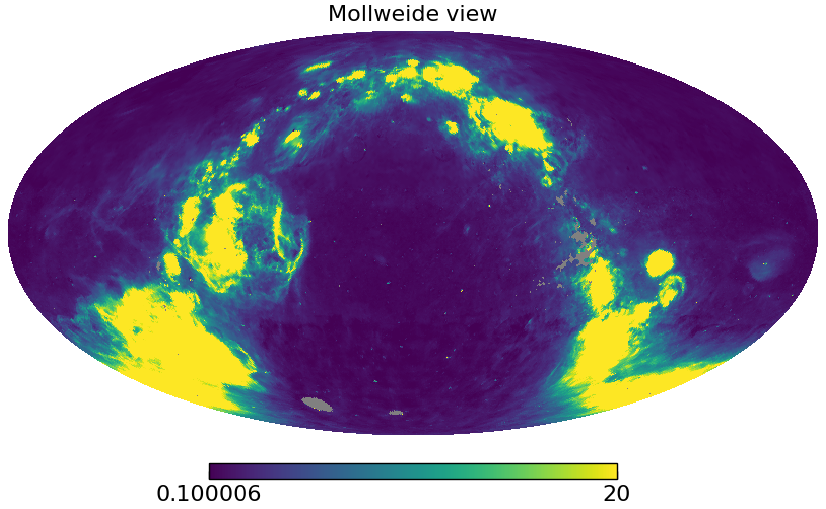

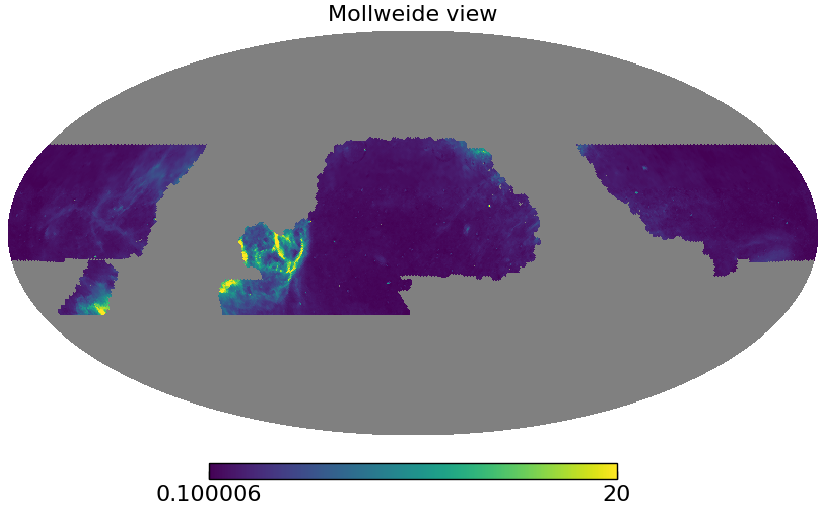

In [78]:
hp.mollview(h_alpha_good_nside[nside_val],max =20 )
hp.mollview(h_alpha_good_masked,max =20  )

In [14]:
counts_randoms = {}
for region in regions.keys():
    dat = regions[region]
    counts_randoms[region] = {}
    for nside in nside_values_obj:
        mask = masks_dict[region][nside]
        counts_randoms[region][nside] = points_to_map(dat['RA'], dat['DEC'], nside=nside)

In [ ]:
# Save all maps and counts_randoms
# for region in regions.keys():
#     for nside in nside_values_obj:
#         # Save each systematic map
#         for map_name, map_data in maps[region][nside].items():
#             filename = f"imaging_systematics_maps/data/{region}_{map_name}_nside_{nside}.fits"
#             hp.write_map(filename, map_data, overwrite=True)
#             print(f"Saved {filename}")
        
#         # Save counts_randoms map
#         counts_filename = f"imaging_systematics_maps/data/{region}_counts_randoms_nside_{nside}.fits"
#         hp.write_map(counts_filename, counts_randoms[region][nside], overwrite=True)
#         print(f"Saved {counts_filename}")

# print("\nAll maps and counts saved successfully!")

setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]


Saved imaging_systematics_maps/data/full_H_Alpha_Good_nside_32.fits
Saved imaging_systematics_maps/data/full_H_Alpha_Good_nside_64.fits
Saved imaging_systematics_maps/data/full_H_Alpha_Good_nside_128.fits
Saved imaging_systematics_maps/data/north_H_Alpha_Good_nside_32.fits
Saved imaging_systematics_maps/data/north_H_Alpha_Good_nside_64.fits
Saved imaging_systematics_maps/data/north_H_Alpha_Good_nside_128.fits
Saved imaging_systematics_maps/data/south_H_Alpha_Good_nside_32.fits
Saved imaging_systematics_maps/data/south_H_Alpha_Good_nside_64.fits
Saved imaging_systematics_maps/data/south_H_Alpha_Good_nside_128.fits

All maps and counts saved successfully!


In [20]:
counts = {}

data={}
data['full'] = Table(fitsio.FITS('../table_match_final.fits')[1].read())
data['north'] = Table(fitsio.FITS(f'../../FP_CUTS/table_north_unique.fits')[1].read())
data['north']= data['north'][data['north']['DEC']>10]

data['south'] = Table(fitsio.FITS(f'../../FP_CUTS/table_south_unique.fits')[1].read())
for region in data.keys():
    dat = data[region]
    counts[region] = {}
    for nside in nside_values_obj:
        mask = masks_dict[region][nside]
        counts[region][nside] = points_to_map(dat['RA'], dat['DEC'], nside=nside)

In [ ]:
# List all the systematic map names
systematics_names = list(maps['full'][32].keys())
print("Systematic maps available:")
for i, name in enumerate(systematics_names, 1):
    print(f"{i}. {name}")